In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder 

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV

from sklearn import metrics 

In [3]:
df = pd.read_csv('../data/churn.csv', header='infer')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset analysis

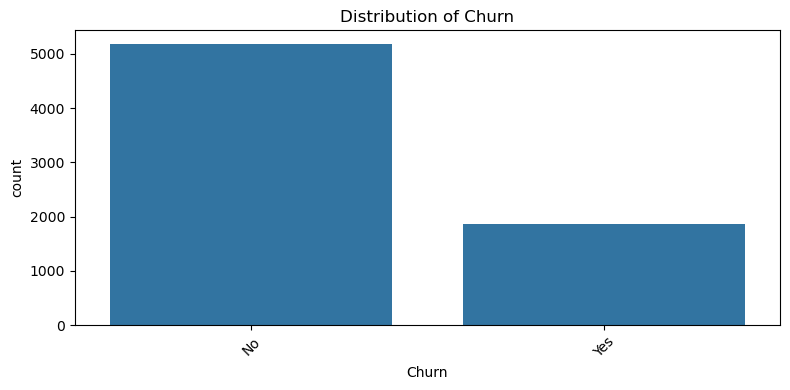

In [117]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x=df["Churn"], order=df["Churn"].value_counts().index)
plt.title(f"Distribution of {"Churn"}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

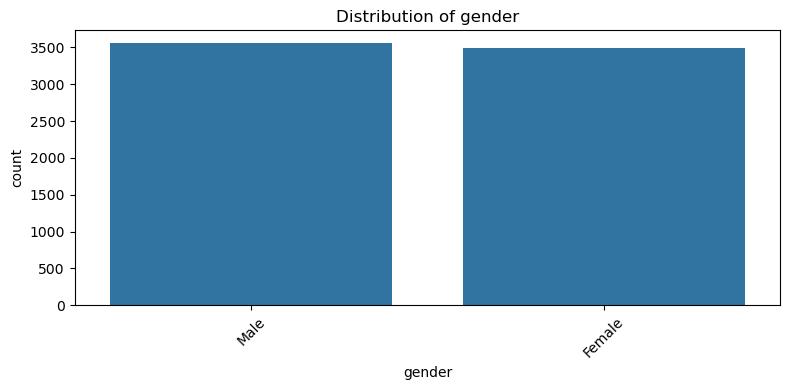

In [120]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x=df["gender"], order=df["gender"].value_counts().index)
plt.title(f"Distribution of {"gender"}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

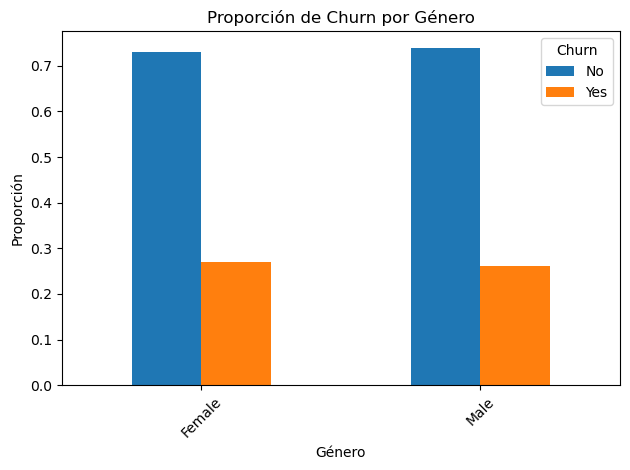

In [119]:
plt.figure(figsize=(8, 4))
churn_by_gender = df.groupby('gender')['Churn'].value_counts(normalize=True).unstack()
churn_by_gender.plot(kind='bar')
plt.title('Proporción de Churn por Género')
plt.xlabel('Género')
plt.ylabel('Proporción')
plt.legend(['No', 'Yes'], title='Churn')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Propietario\AppData\Local\Temp\ipykernel_28880\723105578.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_age = df.groupby('Age_Group')['Churn'].value_counts(normalize=True).unstack()


<Figure size 1000x600 with 0 Axes>

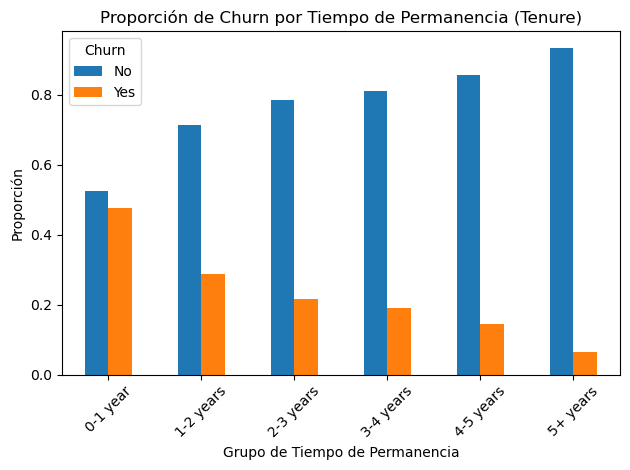

In [121]:
# Create age groups from tenure (converting months to approximate years)
df['Age_Group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 36, 48, 60, float('inf')], 
                         labels=['0-1 year', '1-2 years', '2-3 years', '3-4 years', '4-5 years', '5+ years'])

# Calculate churn proportion by age group
churn_by_age = df.groupby('Age_Group')['Churn'].value_counts(normalize=True).unstack()

# Plot
plt.figure(figsize=(10, 6))
churn_by_age.plot(kind='bar')
plt.title('Proporción de Churn por Tiempo de Permanencia (Tenure)')
plt.xlabel('Grupo de Tiempo de Permanencia')
plt.ylabel('Proporción')
plt.legend(['No', 'Yes'], title='Churn')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.select_dtypes(include=['object', 'category']).nunique()

customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
TotalCharges        6531
Churn                  2
dtype: int64